# 05 — Resampling Leakage & Diagnostic Curves

Two more ways cross-validation keeps you honest, both on the **German Credit** dataset (1,000 rows,
30% "bad" risks).

1. **Resampling leakage** — the trap that catches almost everyone who works with imbalanced data:
   *when* you oversample the minority class decides whether your score is real.
2. **Learning & validation curves** — CV isn't only for a single score; swept across *dataset size*
   and *model complexity* it becomes a diagnostic that tells you **why** a model underperforms and
   **whether more data or a simpler model would help**.

Everything here reuses the discipline from notebook 01: any data-dependent step must happen **inside
the fold**, never before the split.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

from cv_datasets import load_credit, feature_types
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

RS = 0
X, y = load_credit()
num, cat = feature_types(X)
yv = y.to_numpy()

def preprocessor():
    # Encode categoricals + scale numerics INSIDE the pipeline, so it re-fits per fold.
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])

print(f"German Credit: {X.shape[0]} rows, positive ('bad') rate = {yv.mean():.0%}")

German Credit: 1000 rows, positive ('bad') rate = 30%


---
## Part 1 — Resampling leakage: *when* you oversample matters

Imbalanced data (here 70% good / 30% bad) tempts you to **oversample** the minority class so the
model pays it more attention. The most common recipe is **random oversampling**: duplicate minority
rows (with replacement) until the classes are balanced.

Here's the trap. If you oversample the **whole dataset first and then cross-validate**, a minority
row and one of its *duplicate copies* can land in different folds — one in train, its clone in test.
The model isn't generalizing; it's being tested on rows it literally memorized. This is the same
leakage sin as notebook 01, just wearing a different hat: **a data-dependent step (resampling) done
before the split.**

The fix is identical in spirit: oversample **inside each fold's training set only**, and always
evaluate on the untouched, still-imbalanced test rows.

In [2]:
def oversample(X_tr, y_tr, rs=RS):
    # Random oversampling: duplicate minority-class rows (with replacement) up to the
    # majority count. Returns a balanced (X, y).
    idx = np.arange(len(y_tr))
    maj, minr = (0, 1) if (y_tr == 0).sum() > (y_tr == 1).sum() else (1, 0)
    n_add = int((y_tr == maj).sum() - (y_tr == minr).sum())
    extra = resample(idx[y_tr == minr], replace=True, n_samples=n_add, random_state=rs)
    keep = np.concatenate([idx, extra])
    return X_tr.iloc[keep], y_tr[keep]

model = RandomForestClassifier(n_estimators=200, random_state=RS)
cv = StratifiedKFold(5, shuffle=True, random_state=RS)

### The leaky way — oversample everything, *then* cross-validate

In [3]:
# LEAKY: balance the FULL dataset up front, then run ordinary CV on it.
# Duplicated minority rows now leak across the train/test boundary.
X_bal, y_bal = oversample(X, yv)
leaky_auc = cross_val_score(make_pipeline(preprocessor(), model),
                            X_bal, y_bal, cv=cv, scoring="roc_auc").mean()
print(f"Leaky  (oversample before split): AUC = {leaky_auc:.3f}")

Leaky  (oversample before split): AUC = 0.965


### The correct way — oversample *inside* each fold

In [4]:
# CORRECT: for each fold, oversample ONLY the training rows, then score on the
# untouched (still-imbalanced) test rows. No duplicate ever crosses the split.
fold_aucs = []
for tr, te in cv.split(X, yv):
    X_tr, y_tr = oversample(X.iloc[tr], yv[tr])
    pipe = make_pipeline(preprocessor(), model).fit(X_tr, y_tr)
    proba = pipe.predict_proba(X.iloc[te])[:, 1]
    fold_aucs.append(roc_auc_score(yv[te], proba))
correct_auc = float(np.mean(fold_aucs))
print(f"Correct (oversample inside fold): AUC = {correct_auc:.3f}")
print(f"\nFake skill from leakage: +{leaky_auc - correct_auc:.3f} AUC")

Correct (oversample inside fold): AUC = 0.794

Fake skill from leakage: +0.171 AUC


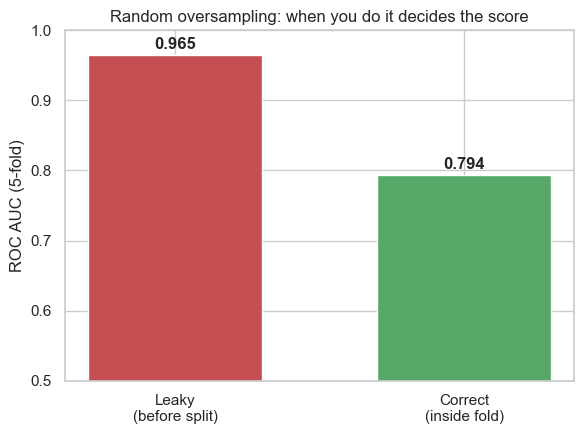

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Leaky\n(before split)", "Correct\n(inside fold)"],
              [leaky_auc, correct_auc], color=["#c44e52", "#55a868"], width=0.6)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC AUC (5-fold)")
ax.set_title("Random oversampling: when you do it decides the score")
for b, v in zip(bars, [leaky_auc, correct_auc]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.008, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

### 📊 How to read this chart

- Both bars are the **same RandomForest**, the same 5-fold CV, the same oversampling recipe — the
  *only* difference is **when** the oversampling happens.
- <span style="color:#c44e52"><b>Leaky</b></span>: balancing the whole dataset first lets duplicate
  minority rows sit in train *and* test. The forest recognizes the memorized rows → inflated AUC.
- <span style="color:#55a868"><b>Correct</b></span>: oversampling only the training fold, and testing
  on untouched rows, gives the honest number.

**Takeaway:** oversampling is a *modeling* step, so it belongs **inside the cross-validation loop**.
Doing it before the split (a one-line convenience) manufactures skill that vanishes in production —
exactly the leakage lesson of notebook 01, now for imbalance handling. In practice, use
`imblearn.pipeline.Pipeline` so SMOTE/oversampling is re-fit per fold automatically.

---
## Part 2 — Learning & validation curves: CV as a *diagnostic*

A single CV score tells you *how good* a model is. Sweep that same CV across two axes and it tells
you **why** — and what to do about it:

- **Learning curve** — vary the *amount of training data*. Answers: *would more data help?*
- **Validation curve** — vary *model complexity* (a hyperparameter). Answers: *am I under- or
  over-fitting, and where's the sweet spot?*

Both plot **training score vs. cross-validated score**. The *gap* between the two lines is the
signature of variance (overfitting); the *level* of the CV line is the signature of bias
(underfitting).

### Learning curve — does more data help?

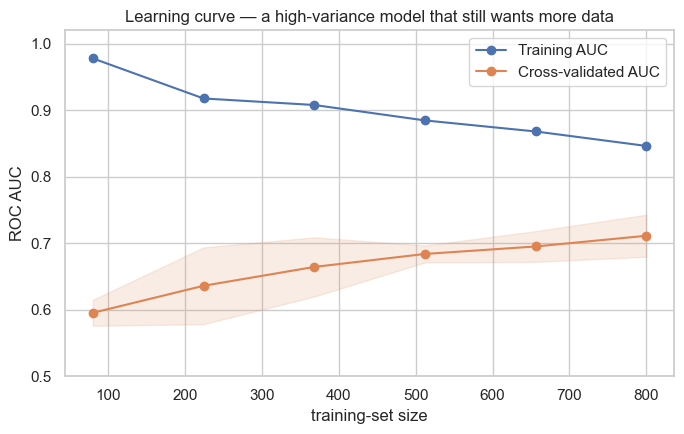

train AUC: [0.978, 0.918, 0.908, 0.885, 0.868, 0.846]
cv    AUC: [0.595, 0.636, 0.664, 0.684, 0.695, 0.711]


In [6]:
# Fix a moderately-complex tree, vary how many rows it trains on.
est = Pipeline([("pre", preprocessor()), ("clf", DecisionTreeClassifier(max_depth=5, random_state=RS))])
sizes, tr_scores, cv_scores = learning_curve(
    est, X, yv, cv=cv, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=RS)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sizes, tr_scores.mean(1), "o-", color="#4c72b0", label="Training AUC")
ax.plot(sizes, cv_scores.mean(1), "o-", color="#dd8452", label="Cross-validated AUC")
ax.fill_between(sizes, cv_scores.mean(1)-cv_scores.std(1), cv_scores.mean(1)+cv_scores.std(1),
                color="#dd8452", alpha=0.15)
ax.set_xlabel("training-set size"); ax.set_ylabel("ROC AUC"); ax.set_ylim(0.5, 1.02)
ax.set_title("Learning curve — a high-variance model that still wants more data")
ax.legend(); plt.tight_layout(); plt.show()

print("train AUC:", [round(v,3) for v in tr_scores.mean(1)])
print("cv    AUC:", [round(v,3) for v in cv_scores.mean(1)])

### 📊 How to read this chart

- The <span style="color:#4c72b0"><b>training</b></span> line starts near-perfect on tiny data (the
  tree memorizes 80 rows easily) and *falls* as more rows make memorization harder.
- The <span style="color:#dd8452"><b>cross-validated</b></span> line *rises* as more data improves
  genuine generalization.
- They're converging but a **gap remains** at the full dataset (~0.85 train vs ~0.71 CV) and the CV
  line is **still climbing** — the two signatures of a **high-variance model that hasn't saturated**.

**Diagnosis:** more data would likely still help, *and* the gap says regularizing (a shallower tree,
an ensemble) would help too. A learning curve that had flattened with a small gap would instead say
"more data won't help — you need a better model or better features."

### Validation curve — how complex should the model be?

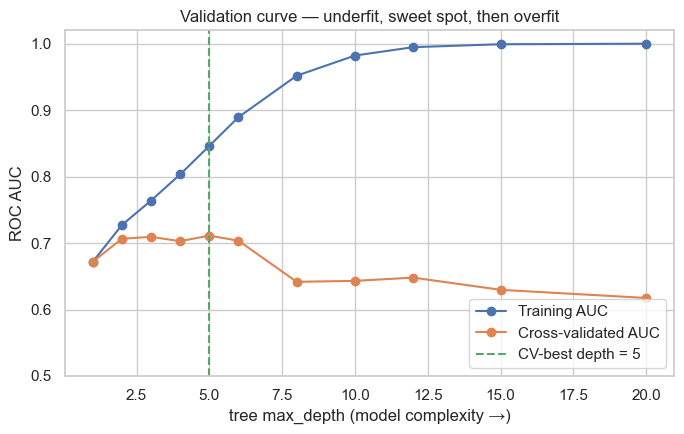

depths  : [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
train   : [0.672, 0.727, 0.764, 0.803, 0.846, 0.889, 0.952, 0.982, 0.995, 0.999, 1.0]
cv      : [0.672, 0.706, 0.709, 0.703, 0.711, 0.704, 0.642, 0.643, 0.648, 0.63, 0.617]
CV picks depth 5 (AUC 0.711)


In [7]:
# Vary tree depth from a stump to a fully-grown tree.
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
est2 = Pipeline([("pre", preprocessor()), ("clf", DecisionTreeClassifier(random_state=RS))])
tr_v, cv_v = validation_curve(est2, X, yv, param_name="clf__max_depth",
                              param_range=depths, cv=cv, scoring="roc_auc")
best_i = int(np.argmax(cv_v.mean(1)))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(depths, tr_v.mean(1), "o-", color="#4c72b0", label="Training AUC")
ax.plot(depths, cv_v.mean(1), "o-", color="#dd8452", label="Cross-validated AUC")
ax.axvline(depths[best_i], ls="--", color="#55a868", label=f"CV-best depth = {depths[best_i]}")
ax.set_xlabel("tree max_depth (model complexity →)"); ax.set_ylabel("ROC AUC"); ax.set_ylim(0.5, 1.02)
ax.set_title("Validation curve — underfit, sweet spot, then overfit")
ax.legend(); plt.tight_layout(); plt.show()

print("depths  :", depths)
print("train   :", [round(v,3) for v in tr_v.mean(1)])
print("cv      :", [round(v,3) for v in cv_v.mean(1)])
print(f"CV picks depth {depths[best_i]} (AUC {cv_v.mean(1).max():.3f})")

### 📊 How to read this chart

- Read left→right as **model complexity increasing**.
- **Left (shallow):** both lines low and together — the model is too simple to fit even the training
  data. That's **underfitting (high bias)**.
- **Middle:** the CV line peaks (here at **depth 5**). This is the **sweet spot** — the complexity
  that generalizes best.
- **Right (deep):** the <span style="color:#4c72b0"><b>training</b></span> line marches to a perfect
  1.0 while the <span style="color:#dd8452"><b>cross-validated</b></span> line *falls*. The widening
  gap is **overfitting (high variance)** — the tree is memorizing noise.

**Takeaway:** the training score always improves with complexity, so it can never tell you when to
stop — only the **cross-validated** score reveals the sweet spot and the overfitting cliff beyond it.
This is exactly what `GridSearchCV` automates (notebook 04); a validation curve is the picture behind
that single `best_params_`.

---
## The through-line

Both halves of this notebook are the same idea from a different angle:

- **Resampling leakage** — a data-dependent step (oversampling) must live *inside* the fold, or it
  leaks. (Notebook 01's Pipeline rule, applied to imbalance.)
- **Curves** — cross-validation isn't just a score, it's a **measuring instrument**. Swept across
  data size and complexity, it diagnoses bias vs. variance and tells you what to fix next.

Honest measurement first; everything else follows.